<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Ciencias-planetarias/punto2_proyecto_planetarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Librerias necesarias:

from __future__ import print_function
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#from astropy.stats.lombscargle import LombScargle
from google.colab import files
from astropy.timeseries import LombScargle
# from gatspy import datasets, periodic
# from PyAstronomy.modelSuite import KeplerRVModel
# from PyAstronomy import funcFit as fuf

from astropy.time import Time
from datetime import datetime

%matplotlib inline

In [ ]:
# luminosidad en funcion de masa

def lum(m):
  lum = np.zeros(len(m))

  for i in range(len(m)):
    if 0.1<m[i]<0.43:
      lum[i]= (m[i])**4
    if 0.43<m[i]<2:
      lum[i]= 0.23*(m[i])**2.3

  return lum

In [ ]:
m = np.linspace(0.1, 1.65, 100)

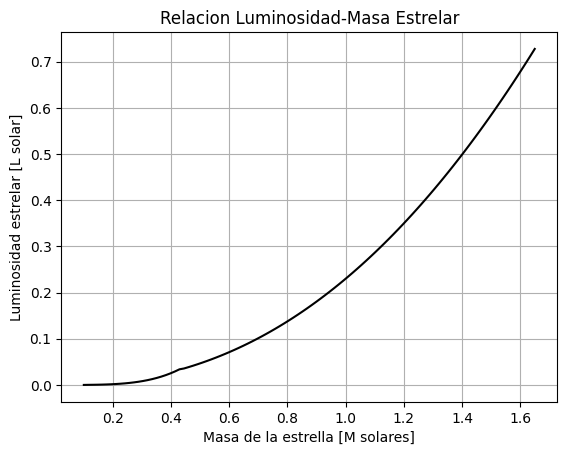

In [ ]:
# modelo
plt.plot(m,lum(m),'k')
plt.title('Relacion Luminosidad-Masa Estrelar')
plt.xlabel('Masa de la estrella [M solares]')
plt.ylabel('Luminosidad estrelar [L solar]')
plt.grid()


In [ ]:
# subir datos
fils = files.upload()


Saving temp_vs_masa.txt to temp_vs_masa.txt


In [ ]:
datos = pd.read_csv('temp_vs_masa.txt', delim_whitespace=True, header=None)

In [ ]:
datos.keys()

Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')

In [ ]:
datos

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.16,<,M,≤,0.25,6,0.217,0.238,3105,5.020,M4.5,10.55,45.7713,0.044
1,0.25,<,M,≤,0.35,5,0.281,0.302,3167,4.926,M3.5,9.95,34.0746,0.057
2,0.35,<,M,≤,0.45,11,0.398,0.395,3282,4.844,M3,9.21,24.4342,0.080
3,0.45,<,M,≤,0.55,12,0.503,0.489,3547,4.761,M1.5,8.41,14.8043,0.130
4,0.55,<,M,≤,0.65,11,0.602,0.612,3924,4.644,K9,7.49,7.5421,0.260
5,0.65,<,M,≤,0.75,14,0.690,0.675,4289,4.618,K4.5,6.89,4.9844,0.390
6,0.75,<,M,≤,0.85,14,0.802,0.798,4663,4.539,K3.5,6.16,2.9687,0.650
7,0.85,<,M,≤,0.95,19,0.907,0.935,5279,4.454,K0,5.28,1.4882,1.300
8,0.95,<,M,≤,1.05,18,1.000,1.092,5498,4.362,G5,4.76,1.0222,1.890
9,1.05,<,M,≤,1.15,21,1.093,1.176,5922,4.336,G3,4.28,0.7156,2.700


In [ ]:
temp_eff = datos[8]
m1 = datos[0]
m2 = datos[4]
mprom= (m1+m2)/2

In [ ]:
from scipy.interpolate import UnivariateSpline # splin ciego

# orden para fiteo

fit = UnivariateSpline(mprom, temp_eff, s=10)
x = np.linspace(0.2, 1.65, 100)

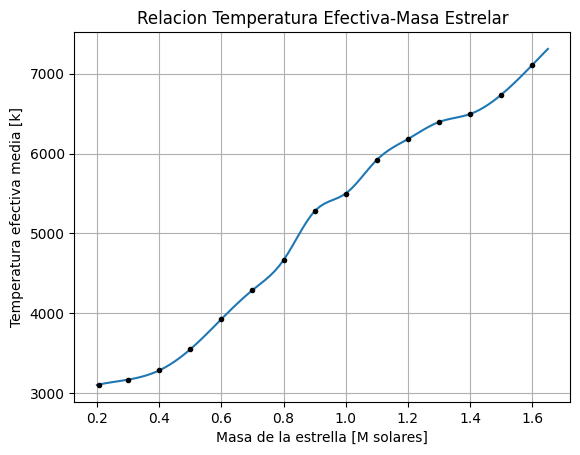

In [ ]:
plt.plot(x,fit(x))
plt.plot(mprom,temp_eff,'k.')
plt.title('Relacion Temperatura Efectiva-Masa Estrelar')
plt.xlabel('Masa de la estrella [M solares]')
plt.ylabel('Temperatura efectiva media [k]')
plt.grid()

t_estr = fit(x) - 5780

In [ ]:
s_eff_sun_venus = 1.7763
s_eff_sun_mars = 0.3207

s_eff_run_green = 1.0385
s_eff_mois_green = 1.0146
s_eff_max_green = 0.3507

a_venus = 1.4335 * (10**-4)
b_venus = 3.3954 * (10**-9)
c_venus = -7.6364 * (10**-12)
d_venus = -1.1950 * (10**-15)

a_mars = 5.4471 * (10**-5)
b_mars = 1.5275 * (10**-9)
c_mars = -2.1709 * (10**-12)
d_mars = -3.8282 * (10**-16)


a_run = 1.2456 * (10**-4)
b_run = 1.4612 * (10**-8)
c_run = -7.6345 * (10**-12)
d_run = -1.7511 * (10**-15)

a_mois = 8.1884 * (10**-5)
b_mois = 1.9394 * (10**-9)
c_mois = -4.3618 * (10**-12)
d_mois = -6.8260 * (10**-16)

a_max = 5.9578 * (10**-5)
b_max = 1.6707 * (10**-9)
c_max = -3.0058 * (10**-12)
d_max = -5.1925 * (10**-16)



s_eff_venus = s_eff_sun_venus + a_venus*t_estr +b_venus*(t_estr**2) +c_venus*(t_estr**3) +d_venus *(t_estr **4)
s_eff_mars = s_eff_sun_mars + a_mars*t_estr +b_mars*(t_estr**2) +c_mars*(t_estr**3) +d_mars *(t_estr **4)


s_eff_run = s_eff_run_green + a_run*t_estr +b_run*(t_estr**2) +c_run*(t_estr**3) +d_run *(t_estr **4)

s_eff_mois = s_eff_mois_green + a_mois*t_estr +b_mois*(t_estr**2) +c_mois*(t_estr**3) +d_mois *(t_estr **4)

s_eff_max = s_eff_max_green + a_max*t_estr +b_max*(t_estr**2) +c_max*(t_estr**3) +d_max *(t_estr **4)

In [ ]:
d_venus = (lum(m)/(s_eff_venus))**0.5

d_mars = (lum(m)/(s_eff_mars))**0.5


d_run = (lum(m)/(s_eff_run))**0.5

d_mois = (lum(m)/(s_eff_mois))**0.5


d_max = (lum(m)/(s_eff_max))**0.5

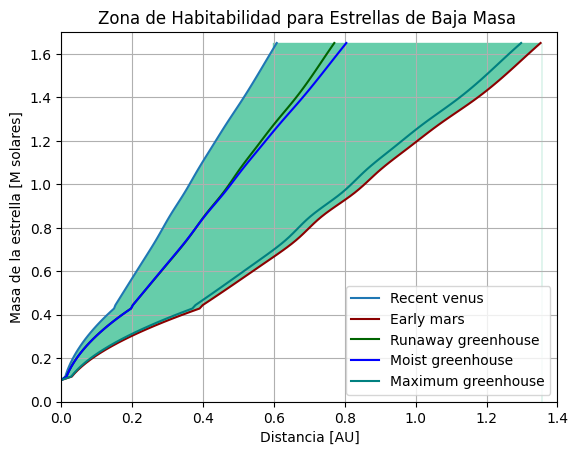

In [ ]:
plt.plot(d_venus,m, label='Recent venus',)
plt.plot(d_mars,m, 'darkred',label='Early mars')

plt.plot(d_run,m, '#006400',label='Runaway greenhouse',)
plt.plot(d_mois,m, 'blue',label='Moist greenhouse')
plt.plot(d_max,m, '#008080',label='Maximum greenhouse')

plt.title('Zona de Habitabilidad para Estrellas de Baja Masa ')
plt.ylabel('Masa de la estrella [M solares]')
plt.xlabel('Distancia [AU]')

plt.xlim(0,1.4)
plt.ylim(0,1.7)

plt.fill_between(d_venus,m, where=(d_venus < max(d_venus)), color='#66CDAA')

rell_x = np.linspace(0.59,max(d_mars),100)

plt.fill_between(rell_x, max(m), where=(d_venus < d_mars) , color='#66CDAA')

plt.fill_between(d_mars,m, color='w')

plt.grid()
plt.legend()
